# Module: Region Similarity

Assuming that transcripts are homogeneously distributed throughout the cell, we expect there to be similar expression of genes in the nucleus and in the rest of the cell. If this is not the case, it can be indicative of transcript spillover from adjacent cells.

<center>
 <img src='../_static/img/docs/region_similarity.png' width='90%' />
</center>

The `region similarity` (`rs`) module provides metrics to assess how similar the expression profiles are between subcellular regions (e.g., cell and nucleus). 

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/iGxVy8qtZnwHOju).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa
from scipy.stats import linregress

import segtraq

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you wa

We start out by loading the data into a `SegTraQ` object.

In [3]:
# loading the spatialdata object
sdata = sd.read_zarr("../../data/xenium_v1_data/sdata_proseg_v3_crop.zarr")

# putting the object into a SegTraQ object
st = segtraq.SegTraQ(
    sdata,
    points_cell_id_key="assignment",
    points_background_id=None,
    points_gene_key="gene",
    tables_area_key=None,
    tables_cell_id_key="cell",
    shapes_cell_id_key="cell",
    tables_centroid_x_key="centroid_x",
    tables_centroid_y_key="centroid_y",
)

# removing control transcripts
st.filter_control_and_low_quality_transcripts(min_qv=None)

sdata

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/SegTraQ.py:116: RuntimeWarning: No area column specified for tables. Area will be automatically computed from shapes.
  validate_spatialdata(


SpatialData object, with associated Zarr store: /g/huber/projects/CODEX/segtraq/data/20260204_SegTraQ_sdata/xenium_v1_data/sdata_proseg_v3_crop.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 2500, 2500), (1, 1250, 1250), (1, 625, 625), (1, 313, 313), (1, 156, 156)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (1533, 1) (2D shapes)
│     ├── 'cell_boundaries_z0': GeoDataFrame shape: (1518, 2) (2D shapes)
│     ├── 'cell_boundaries_z1': GeoDataFrame shape: (1520, 2) (2D shapes)
│     ├── 'cell_boundaries_z2': GeoDataFrame shape: (1507, 2) (2D shapes)
│     ├── 'cell_boundaries_z3': GeoDataFrame shape: (1305, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (1501, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (1533, 313)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), transcripts (Points), cell_boundaries (

As you can see, the `spatialdata`dataset contains cell and nuclear masks as `shapes`. It is important that you have a nuclear segmentation in your object, otherwise you will not be able to compute the metrics below.

## Intersection over Union between cell and nucleus masks

First, we get the nucleus that overlaps most with each cell and compute the Intersection over Union (IoU) between cell and nuclear masks using the method `match_nuclei_to_cells()`.

In [4]:
results_df = st.rs.match_nuclei_to_cells()
results_df.head()

,cell,nucleus_id,iou,nucleus_fraction
0,70066,78094.0,0.372469,0.909792
1,70067,NaN,NaN,NaN
2,70069,78081.0,0.621191,0.938538
3,70070,78084.0,0.357129,0.969828
4,70071,78083.0,0.662761,0.994992


For each `cell_id`, we obtain the ID (`nucleus_id`) of the nucleus mask with the highest `IoU`. If a cell does not overlap with any nucleus, the function returns a missing value for `nucleus_id`. In addition to the `IoU`, we also report the fraction of the nucleus that overlaps with the cell. If the nucleus has an invalid geometry, `IoU` and `nucleus_fraction` are reported as `NA`.

Let's see what this looks like when we plot the IoU spatially.

WARNING  Found 35 NaN values in color data. These observations will be colored with the 'na_color'.                


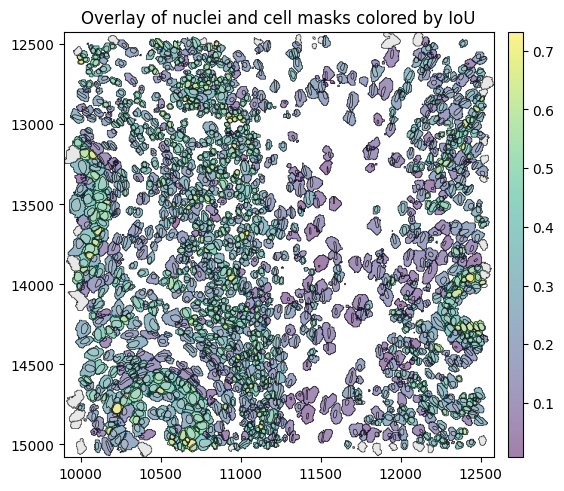

In [5]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

# plot
sdata.pl.render_shapes(
    element="cell_boundaries",
    color="iou",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(title="Overlay of nuclei and cell masks colored by IoU", colorbar=True)

We will quickly set up some helper functions to facilitate plotting.

In [6]:
# helper functions for plotting
def plot_histogram(
    df,
    column,
    bins=30,
    figsize=(6, 5),
    color="steelblue",
    edgecolor="black",
    show_median=True,
    median_kwargs=None,
    median_color="red",
    title=None,
    xlabel=None,
    ylabel="Count",
    ax=None,
):
    values = df[column].dropna()
    median_value = np.median(values)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    ax.hist(values, bins=bins, color=color, edgecolor=edgecolor)

    if show_median:
        median_kwargs = median_kwargs or {}
        ax.axvline(
            median_value,
            linestyle="--",
            linewidth=2,
            color=median_color,
            label=f"Median = {median_value:.2f}",
            **median_kwargs,
        )
        ax.legend()

    ax.set_title(title or f"Distribution of {column}")
    ax.set_xlabel(xlabel or column)
    ax.set_ylabel(ylabel)

    plt.show()


def plot_regression(
    df,
    x,
    y,
    figsize=(6, 6),
    dropna=True,
    ci=95,
    scatter_kws=None,
    line_kws=None,
    title=None,
    xlabel=None,
    ylabel=None,
    r2_loc=(0.05, 0.95),
    r2_fmt="{:.3f}",
    ax=None,
):
    data = df[[x, y]]
    if dropna:
        data = data.dropna()

    # Regression stats
    slope, intercept, r_value, p_value, std_err = linregress(data[x], data[y])
    r_squared = r_value**2

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    scatter_kws = scatter_kws or {"alpha": 0.6}
    line_kws = line_kws or {"color": "red"}

    sns.regplot(
        data=data,
        x=x,
        y=y,
        ci=ci,
        scatter_kws=scatter_kws,
        line_kws=line_kws,
        ax=ax,
    )

    # R² annotation
    ax.text(
        r2_loc[0],
        r2_loc[1],
        rf"$R^2 = {r2_fmt.format(r_squared)}$",
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.set_title(title or f"{y} vs. {x}")
    ax.grid(True)

    plt.show()

We can now investigate what the distribution of IoUs looks like.

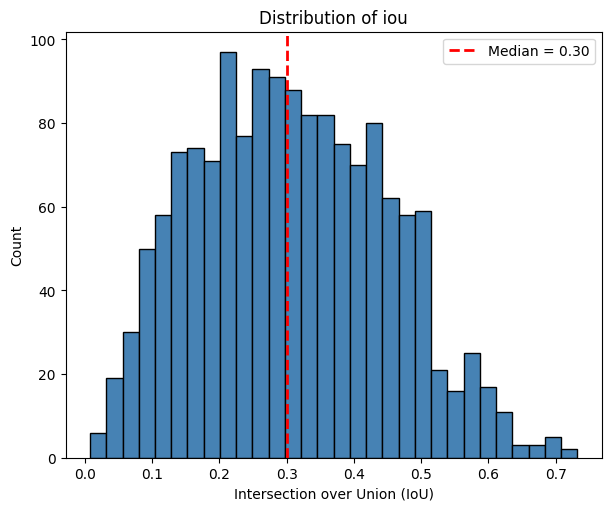

In [7]:
plot_histogram(
    df=sdata["table"].obs,
    column="iou",
    xlabel="Intersection over Union (IoU)",
)

## Expression similarity between cell and nucleus

Now that we have matched each cell with a nucleus, we can investigate how similar the expression profiles are between the nucleus and the whole cell (including the nucleus). For this, we use the function `similarity_nucleus_cell()`.

In [8]:
similarity_df = st.rs.similarity_nucleus_cell(metric="cosine_sim")

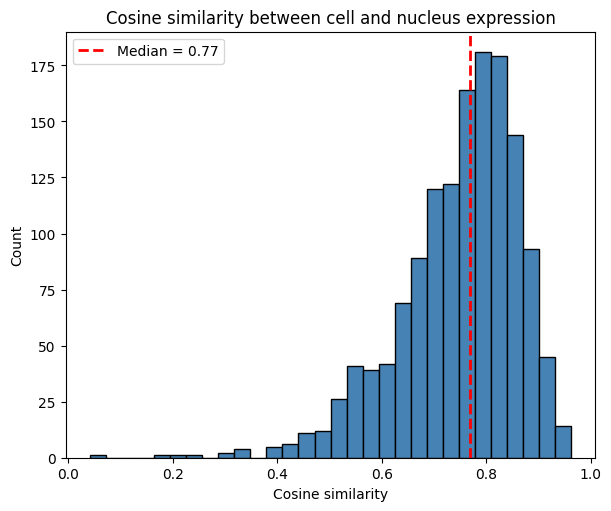

In [9]:
plot_histogram(
    df=sdata["table"].obs,
    column="similarity_nucleus_cell",
    title="Cosine similarity between cell and nucleus expression",
    xlabel="Cosine similarity",
)

The histogram shows the distribution of cosine similarity values across cells. It is right-skewed, with a median of 0.77. This provides intuition about possible spatial spillover: cells may be contaminated by neighboring cells, assuming that nuclei capture expression with less contamination due to their smaller radius.

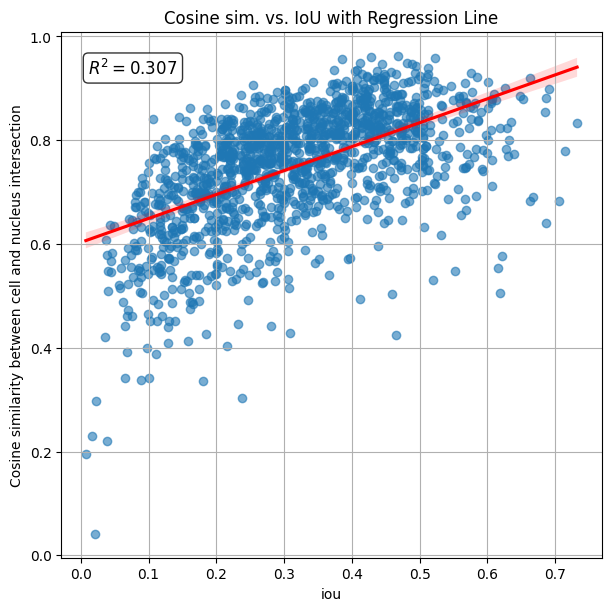

In [10]:
plot_regression(
    df=sdata["table"].obs,
    x="iou",
    y="similarity_nucleus_cell",
    title="Cosine sim. vs. IoU with Regression Line",
    ylabel="Cosine similarity between cell and nucleus intersection",
)

The calculated R2 (coefficient of determination) is 0.307, indicating that similarity/correlation between cell and nucleus increases with their IoU. 

The spatial plot below shows cell boundaries colored by cosine similarity between the nucleus and the cell. Cells whose transcripts are distributed across the nucleus region tend to have higher similarity with the nucleus, while cells whose transcripts are located outside the nuclear region —potentially due to spillover from neighboring cells— tend to exhibit lower similarity.

WARNING  Found 35 NaN values in color data. These observations will be colored with the 'na_color'.                
WARNING  Found 121 NaN values in color data. These observations will be colored with the 'na_color'.               


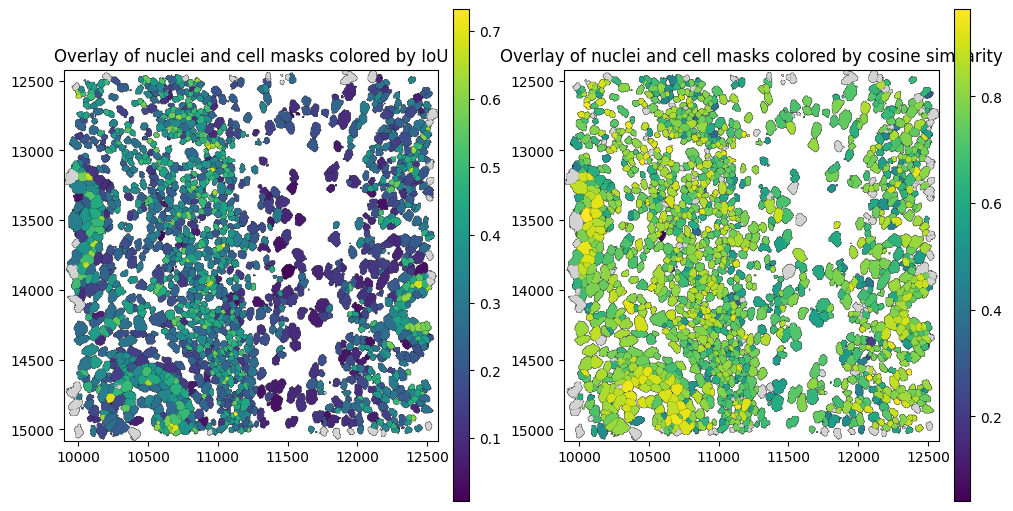

In [11]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

# plot
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

sdata.pl.render_shapes(
    element="cell_boundaries",
    color="iou",
    cmap="viridis",
    fill_alpha=1.0,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=ax[0], title="Overlay of nuclei and cell masks colored by IoU", colorbar=True)

sdata.pl.render_shapes(
    element="cell_boundaries",
    color="similarity_nucleus_cell",
    cmap="viridis",
    fill_alpha=1.0,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(ax=ax[1], title="Overlay of nuclei and cell masks colored by cosine similarity", colorbar=True)

Let's have a look at some cells witha low IoU, but a high similarity between the nucleus and the whole cell.

In [12]:
obs = sdata["table"].obs
df = obs[["cell", "iou", "similarity_nucleus_cell"]].dropna()
df.loc[df["iou"] < 0.1].sort_values("similarity_nucleus_cell", ascending=False).head()

,cell,iou,similarity_nucleus_cell
70961,70961,0.099841,0.738821
75471,75471,0.091001,0.727011
71219,71219,0.095490,0.714954
70949,70949,0.090434,0.713838
72782,72782,0.084363,0.700521


We can see that there are some cells with high `similarity_nucleus_cell` despite low `IoU`. Let's investigate one of these cells in more detail. By plotting the cell (centroid marked by grey cross) with its nucleus (centroid marked by black cross) and assigned transcripts (red), we can see that for this cell, the nucleus is small in comparison to the cell, however the transcripts are still somewhat homogeneously distributed within the cell, leading to the high similarity.

In [13]:
cid = (
    df.loc[df["iou"] < 0.1]
    .dropna(subset=["similarity_nucleus_cell"])
    .sort_values("similarity_nucleus_cell", ascending=False)
    .iloc[0]["cell"]
)
cid

np.float64(70961.0)

In [17]:
# helper function for plotting
def plot_cell_with_nucleus_and_transcripts(
    cid: float | int,
    title: str,
    pix_to_um_scale_factor: float = 0.2125,
    repositioned_transcripts: bool = False,
    padding=200,
    genes=None,
    center_layer="nucleus_boundaries",
    outer_layer="cell_boundaries",
):
    # add annotation of this cell to .obs
    sdata["table"].obs["focal_cell"] = sdata["table"].obs.index == cid

    # compute x,y of cell and nucleus centroids in µm space
    centroid_x_cell_px = sdata["cell_boundaries"].loc[cid].geometry.centroid.x
    centroid_y_cell_px = sdata["cell_boundaries"].loc[cid].geometry.centroid.y
    centroid_x_cell = centroid_x_cell_px / pix_to_um_scale_factor
    centroid_y_cell = centroid_y_cell_px / pix_to_um_scale_factor

    nid = sdata["table"].obs.loc[sdata["table"].obs["cell"] == cid, "nucleus_id"]
    centroid_x_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.x / pix_to_um_scale_factor
    centroid_y_nucleus = sdata["nucleus_boundaries"].loc[nid].geometry.centroid.y / pix_to_um_scale_factor

    # add annotation of this cell to .points and build new `PointsModel``
    trans = sdata.points["transcripts"].compute()
    trans["focal_cell"] = "other_cells"
    trans.loc[trans["assignment"] == cid, "focal_cell"] = "focal_cell"
    trans["focal_cell"] = trans["focal_cell"].astype("category")
    if repositioned_transcripts:
        trans = trans.drop(columns=["x", "y", "z"])
        trans = trans.rename(columns={"repositioned_x": "x", "repositioned_y": "y", "repositioned_z": "z"})
    sdata.points["transcripts_2"] = sd.models.PointsModel.parse(trans)
    T = sd.transformations.get_transformation(sdata.points["transcripts"])
    sd.transformations.set_transformation(sdata.points["transcripts_2"], T)
    
    print("transcripts_2" in sdata.points.keys())

    # zoom in for better visibility
    sdata_cropped = sdata.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[centroid_x_cell - padding, centroid_y_cell - padding],
        max_coordinate=[centroid_x_cell + padding, centroid_y_cell + padding],
        target_coordinate_system="global",
    )

    # TODO: temporary, delete this!
    print("transcripts_2" in sdata.points.keys())
    print("transcripts_2" in sdata_cropped.points.keys())

    # plot cell and transcripts of that cell
    axes = plt.subplots(1, 1, figsize=(8, 8), constrained_layout=True)[1]

    plot = sdata_cropped.pl.render_shapes(
        element=center_layer,
        fill_alpha=0.2,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="black",
    ).pl.render_shapes(
        element=outer_layer,
        color="focal_cell",
        fill_alpha=0.1,
        outline_alpha=1.0,
        outline_width=0.5,
        outline_color="blue",
    )

    if genes is None:
        plot = plot.pl.render_points(
            "transcripts_2",
            color="focal_cell",
            fill_alpha=0.1,
            groups=["focal_cell"],
            palette=["red"],
        )
    else:
        plot = plot.pl.render_points(
            "transcripts",
            color="gene",
            fill_alpha=0.1,
            groups=genes,
            palette=["red"],
        )

    plot.pl.show(
        ax=axes,
        title=title,
        colorbar=True,
    )

    # landmark for cell and nucleus centroid
    axes.scatter([centroid_x_cell], [centroid_y_cell], marker="+", s=400, c="black", linewidths=2, zorder=10, alpha=0.4)
    axes.scatter([centroid_x_nucleus], [centroid_y_nucleus], marker="+", s=400, c="black", linewidths=2, zorder=10)

In [21]:
# TODO: temporary
sdata  # .points['transcripts_2']
print(sd.__file__)
sd.__version__

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/__init__.py


'0.7.2'

True
True
False


KeyError: "Could not find element with name 'transcripts_2'"

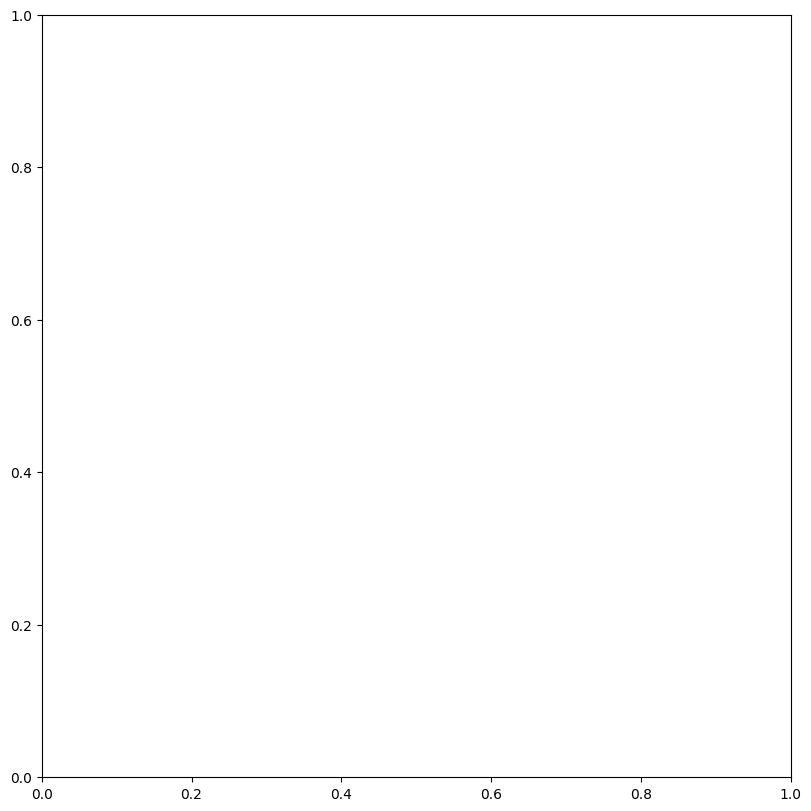

In [19]:
plot_cell_with_nucleus_and_transcripts(cid, title="Cell with high similarity_nucleus_cell despite high IoU")

Instead of the true (raw) coordinates, we can also plot the repositioned coordinates of transcripts, which shows that proseg places them inside the cell. 

In [ ]:
plot_cell_with_nucleus_and_transcripts(cid, repositioned_transcripts=True, title="Repositioned transcripts")

Such cells can be identified easily via the metric `perc_outside_cell`, which comptues the percentage of transcripts that are assigned to a cell, but localized outside its border.

In [ ]:
st.ps.percentage_transcripts_in_compartments().head()

So, just looking at the similarity between the nucleus and the entire cell isn't specific enough. As a better metric, we therefore compute the similarity between the transcripts in the cell region intersecting the nucleus and the transcripts in the remaining cell region (we call this the cytoplasm, however with Proseg, this can also include transcripts that were originally measured outside of the cell, as shown above). 

## Similarity between Nucleus and Cytoplasm

The function `similarity_nucleus_cytoplasm()` computes the cosine similarity between the spatial transcript feature counts within the nucleus and the cytoplasm. It is applicable only when nuclear masks are available. It returns `NaN` when the regions have no or not a sufficient number of overlapping transcripts (`min_transcripts`, `min_genes`). A low correlation/similarity may indicate that the cell boundary extension captures neighborhood or ambient signal rather than true intracellular expression—a concern similarly highlighted by segmentation benchmarks such as [Baysor](https://www.nature.com/articles/s41587-021-01044-w). This is based on the assumption that transcripts are homogeneously distributed within the cell and not localized in specific subcellular regions. 

In [ ]:
sim_nuc_cyto_df = st.rs.similarity_nucleus_cytoplasm()
sim_nuc_cyto_df.head()

The histogram below shows that the cosine similarity between the nucleus and remaining part of the cell is 0.47. 

In [ ]:
plot_histogram(
    df=sdata["table"].obs,
    column="similarity_nucleus_cytoplasm",
    xlabel="Cosine Similarity - Nucleus vs. Cytoplasm",
)

The scatter plot below visualizes the cosine similarity between transcript counts in the intersection and remainder of each cell, plotted against the Intersection over Union (IoU) with the nucleus. The calculated R2 value is 0.006, indicating that `similarity_nucleus_cytoplasm` is independent of `IoU`.

In [ ]:
plot_regression(
    df=sdata["table"].obs,
    x="iou",
    y="similarity_nucleus_cytoplasm",
    title="Cosine sim. vs. IoU with Regression Line",
    ylabel="Cosine similarity between nucleus and cytoplasm",
)

The spatial plots below shows the spatial distribution of computed correlations. The cosine similarity between parts can be a measure of how much neighboring signal is captured. 

In [ ]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)[1].flatten()

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_width=0.5,
    outline_alpha=1.0,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="iou",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[0],
    title="Intersection over Union (IoU)",
    colorbar=True,
    figsize=(6, 6),
)

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="similarity_nucleus_cell",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[1],
    title="Nucleus vs. whole cell",
    colorbar=True,
    figsize=(6, 6),
)

sdata.pl.render_shapes(
    element="nucleus_boundaries",
    fill_alpha=0.2,
    outline_width=0.5,
    outline_alpha=1.0,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="similarity_nucleus_cytoplasm",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[2],
    title="Nucleus vs. cytoplasm",
    colorbar=True,
    figsize=(6, 6),
)

Above, we can see that there are some cells with low cosine similarity between parts despite high `IoU`. Let's investigate these. This happens when the transcripts of a gene are only localized in the nucleus but not in the cytoplasm or vice versa.

In [ ]:
obs = sdata.tables["table"].obs
cid = (
    obs.loc[obs["iou"] > 0.65]
    .dropna(subset=["similarity_nucleus_cytoplasm"])
    .sort_values("similarity_nucleus_cytoplasm")
    .iloc[0]["cell"]
)
cid

In [ ]:
plot_cell_with_nucleus_and_transcripts(
    cid, title="Cell with low cosine similarity between nucleus and cytoplasm despite high IoU"
)

## Similarity between the cell border with its neigbhorhood
The function `similarity_nucleus_cytoplasm()` computes the cosine similarity between (1) the cell border and an eroded interior and (2) the cell border and the immediate neighborhood.

Specifically, the function:
1. Erodes each cell polygon to obtain a center region.
2. Defines the border region as the set difference between the full cell
   and its eroded center.
3. Computes gene expression profiles for center and border.
4. Computes the correlation between center and border expression.
5. Computes the correlation between border expression and the
   neighborhood expression profile.
6. The ratio of the latter two

In [ ]:
border_nhood_df = st.rs.similarity_border_neighborhood()

In [ ]:
border_nhood_df.head()

The histogram below shows the distribution of the correlation between the cell center and border.

In [ ]:
plot_histogram(
    df=sdata["table"].obs,
    column="similarity_center_border",
    xlabel="Cosine Similarity - Cell center vs. border",
)

The histogram below shows the distribution of the correlation between the cell border and its neigbhorhood (with a distance of twice cell radius from its centroid). As expected, the correlation to the cell center is higher than to the cell neighborhood. This will differ depending on whether the cell is located within a homogeneous or a heterogeneous neighborhood.

In [ ]:
plot_histogram(
    df=sdata["table"].obs,
    column="similarity_border_neighborhood",
    xlabel="Cosine Similarity - Cell border vs. neighborhoos",
)

The scatter plot below visualizes the cosine similarity between the cell border and its neigbhorhood plotted against the cosine simiarity between the cell border and cell center. The calculated R2 (coefficient of determination) value is 0.323. 

In [ ]:
plot_regression(
    df=sdata["table"].obs,
    x="similarity_center_border",
    y="similarity_border_neighborhood",
)

The spatial plots below shows the spatial distribution of computed correlations. 

In [ ]:
# link annotations with cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)[1].flatten()

sdata.pl.render_shapes(
    element="cell_centers",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="similarity_center_border",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.show(
    ax=axes[0],
    title="Similarity: center vs. border",
    colorbar=True,
    figsize=(6, 6),
)


sdata.pl.render_shapes("cell_boundaries", color="similarity_center_border").pl.show(
    ax=axes[1], title="Similarity: center vs. border", coordinate_systems="global"
)

sdata.pl.render_shapes("cell_boundaries", color="similarity_border_neighborhood").pl.show(
    ax=axes[2], title="Similarity: border vs. neighborhood", coordinate_systems="global"
)

sdata.pl.render_shapes("cell_boundaries", color="ratio_border_neighborhood_to_center").pl.show(
    ax=axes[3], title="Ratio: sim_border_center/sim_border_nhood", coordinate_systems="global"
)

Let's investigate an example cell with one of the highest `ratio_border_neighborhood_to_center`.

In [ ]:
obs = sdata.tables["table"].obs
cid = obs.sort_values("ratio_border_neighborhood_to_center", ascending=False).iloc[0]["cell"]
cid

We select one of the most highly abundant genes in this cell, `CCDC80`. The plot below shows that CCDC80 is distributed across the cell (yellow) border and its neighborhood, but absent from the cell center. 

In [ ]:
tx = sdata.points["transcripts"].compute()
tx.loc[tx["assignment"] == cid, "gene"].value_counts()

In [ ]:
plot_cell_with_nucleus_and_transcripts(
    cid,
    title="Cell with high ratio_border_neighborhood_to_center",
    center_layer="cell_centers",
    outer_layer="cell_boundaries",
    repositioned_transcripts=True,
    genes=["CCDC80"],
)

All of the metrics are also stored in the spatialdata object.

In [ ]:
sdata.tables["table"]

## Session Info

In [ ]:
print(sd.__version__)  # spatialdata
print(spatialdata_plot.__version__)